In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("/content/Data Python Credifamilia.xlsx")
df.head(1)

,Matrícula,Apellido,Nombre,Categoría,Departamento,Sección,Salario,Fecha ingreso,Fch nacimiento
0,1011,Gorton,Hazel,Auxiliar Contable,Contabilidad,Copiadoras,"$27,598",2021-12-12,2012-09-29


1. **Empleados con Salario Anualizado**

   - **Enunciado:** Calcula el salario anualizado (multiplicando el salario mensual por 12) para cada empleado y agrega una columna "Salario Anualizado". Luego, filtra a los empleados cuyo salario anualizado sea mayor a $360,000.

In [ ]:
df["Salario"] = df["Salario"].str.replace("$", "")
df["Salario"] = df["Salario"].str.replace(",", "")

df["Salario"] = df["Salario"].astype(int)

df["Salario Anualizado"] = df["Salario"] * 12
df[df["Salario Anualizado"] > 360000]

,Matrícula,Apellido,Nombre,Categoría,Departamento,Sección,Salario,Fecha ingreso,Fch nacimiento,Salario Anualizado
1,1012,Preston,Liza,Ing. Mecánico,Ingeniería,Impresoras,43394,2010-09-17,1989-07-24,520728
5,1056,Gonzales,Joe,Director Unidad,Administración,Copiadoras,116511,2004-06-15,1962-04-15,1398132
6,1067,Scote,Gail,Especialista Diseño,Diseño,Fax,36940,2012-05-11,1986-05-22,443280
7,1068,Mann,Alyssa,Ing. Mecánico,Ingeniería,Impresoras,47883,2021-03-12,1996-04-10,574596
9,1076,McKormick,Brad,Ingeniero Jefe,Ingeniería,Copiadoras,105753,2014-01-27,1975-03-09,1269036
...,...,...,...,...,...,...,...,...,...,...
107,1968,Martinez,Sara,Respon. Producto,Mercado,Copiadoras,35989,1993-01-01,1969-05-19,431868
108,1969,West,Cara,Representante,Mercado,Impresoras,58278,1989-04-14,1951-10-02,699336
111,1977,Maguire,Mollie,Especialista Diseño,Diseño,Copiadoras,30014,1980-06-13,1967-09-15,360168
112,1977,Gladstone,Wes,Ing. Software,Ingeniería,Fax,48786,1991-09-09,1960-10-13,585432


2. **Antigüedad Promedio por Sección**

   - **Enunciado:** Calcula la antigüedad promedio de los empleados en cada sección. Agrega una columna "Antigüedad Promedio Sección" a la tabla que indique la antigüedad promedio de la sección a la que pertenece cada empleado.

In [ ]:
df["Fecha Corte"] = '2024-08-01'
df["Fecha Corte"] = pd.to_datetime(df["Fecha Corte"])
df["Fecha ingreso"] = pd.to_datetime(df["Fecha ingreso"])

df["Años en Empresa"] = (df["Fecha Corte"] - df["Fecha ingreso"]).dt.days / 365.5

df.groupby("Departamento")["Años en Empresa"].mean().reset_index(name = "Antiguedad Promedio Seccion").sort_values(ascending = False,
                                                                                                                   by = "Antiguedad Promedio Seccion")

,Departamento,Antiguedad Promedio Seccion
0,Administración,31.231190
5,Mercado,29.441966
3,I + D,27.203582
2,Diseño,27.101915
4,Ingeniería,25.566181
1,Contabilidad,24.403361


3. **Cambios en el Salario**

   - **Enunciado:** Crea una columna “Cambio de Salario” que indique el cambio porcentual en el salario respecto al salario inicial registrado en una fecha anterior (puedes simular datos de salario anterior). Calcula el empleado con mayor incremento porcentual en su salario.

In [ ]:
df = df.rename(columns = {"Salario": "Salario Actual"})

minimo = df["Salario Actual"].min()
maximo = df["Salario Actual"].max()

df["Salario Anterior"] = np.round(np.random.normal(minimo, maximo)).astype(int)

In [ ]:
df["Dif. Salario Anterior/Actual"] = df["Salario Actual"] - df["Salario Anterior"]

df["Incremento de Salario"] = np.round((100 * df["Dif. Salario Anterior/Actual"]) / df["Salario Anterior"], 1)

print(f"El empleado con menor incremento de salario es del", df["Incremento de Salario"].min(), "%")
print(f"El empleado con mayor incremento de salario es del", df["Incremento de Salario"].max(), "%")

El empleado con menor incremento de salario es del -81.6 %
El empleado con mayor incremento de salario es del 0.6 %


4. **Agrupación y Agregación Compleja**

   - **Enunciado:** Para cada departamento, calcula la desviación estándar del salario, la media de la antigüedad y el número de empleados. Muestra el resultado en un DataFrame con estos tres valores para cada departamento.

In [ ]:
std = df.groupby("Departamento")["Salario Actual"].std().reset_index(name = "STD").sort_values(by = "Departamento", ascending = False)
std["STD"] = round(std["STD"],2)

promedio = df.groupby("Departamento")["Años en Empresa"].mean().reset_index(name = "Mean").sort_values(by = "Departamento", ascending = False)
promedio["Mean"] = round(promedio["Mean"],2)

empleados = df.groupby("Departamento").size().reset_index(name = "Empleados").sort_values(by = "Departamento", ascending = False)

agregacion = {"Departamento": std["Departamento"],
              "STD Salario": std["STD"],
              "Promedio Antiguedad": promedio["Mean"],
              "Q. Empleados": empleados["Empleados"]
    }

agregacion = pd.DataFrame(data = agregacion)
agregacion

,Departamento,STD Salario,Promedio Antiguedad,Q. Empleados
5,Mercado,20800.16,29.44,26
4,Ingeniería,18753.16,25.57,41
3,I + D,14104.41,27.20,11
2,Diseño,6128.52,27.10,8
1,Contabilidad,6058.02,24.40,14
0,Administración,28229.16,31.23,14


5. **Clasificación de Empleados por Rango de Edad**

   - **Enunciado:** Agrega una columna “Rango de Edad” que clasifique a los empleados en los siguientes rangos: “Menor de 30”, “30-39”, “40-49”, “50 o más”. Calcula el salario promedio para cada rango de edad.

In [ ]:
df["Edad"] = df["Fecha Corte"].dt.year - df["Fch nacimiento"].dt.year

def edad_rango(x):
  if x < 30:
    return "Menor de 30"
  elif 30 <= x <= 39:
    return "Entre 30 y 39"
  elif 40 <= x <= 49:
    return "Entre 40 y 49"
  elif 50 <= x:
    return "Mayor de 50"

df["Rango de edad"] = df["Edad"].apply(lambda x: edad_rango(x))

df.groupby("Rango de edad")["Salario Actual"].mean().reset_index(name = "Salario promedio").sort_values(by = "Salario promedio",
                                                                                                        ascending = False)

,Rango de edad,Salario promedio
1,Entre 40 y 49,49230.538462
2,Mayor de 50,44731.416667
0,Entre 30 y 39,37328.166667
3,Menor de 30,33832.235294


6. **Empleados con Mayor Diferencia de Edad en la Misma Sección**

   - **Enunciado:** Encuentra el par de empleados en cada sección que tengan la mayor diferencia en años de edad. Muestra el nombre de ambos empleados, la sección y la diferencia en edad.

In [ ]:
minimas = df.groupby(["Departamento"])["Edad"].min().reset_index(name = "Edad")
minimas = minimas.merge(df, how = "left", on = ["Departamento", "Edad"])
minimas = minimas[["Departamento", "Nombre", "Edad"]]
minimas = minimas.rename(columns = {"Nombre": "Nombre Minimo", "Edad": "Edad Minima"})


maximas = df.groupby(["Departamento"])["Edad"].max().reset_index(name = "Edad")
maximas = maximas.merge(df, how = "left", on = ["Departamento", "Edad"])
maximas = maximas[["Departamento", "Nombre", "Edad"]]
maximas = maximas.rename(columns={"Nombre": "Nombre Maximo", "Edad": "Edad Maxima"})

diferencia = minimas.merge(maximas, how = "left", on = "Departamento")
diferencia["Diferencia de edad"] = diferencia["Edad Maxima"] - diferencia["Edad Minima"]
diferencia.sort_values(by = "Diferencia de edad", ascending = False)

,Departamento,Nombre Minimo,Edad Minima,Nombre Maximo,Edad Maxima,Diferencia de edad
1,Contabilidad,Hazel,12,Ellen,75,63
4,Ingeniería,Toni,22,Cathy,84,62
5,Ingeniería,Jeremy,22,Cathy,84,62
6,Mercado,Sam,20,Hilda,79,59
0,Administración,Ellen,27,Erika,73,46
2,Diseño,Sheryl,20,Ed,64,44
3,I + D,Felix,27,David,66,39


7. **Comparación de Salarios por Generación**

   - **Enunciado:** Compara los salarios promedio y la desviación estándar de los salarios entre las diferentes generaciones. Usa gráficos para visualizar las diferencias.

<ipython-input-11-07757bbe6e2f>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = dif_salario, x = "Rango de edad", y = "Promedio Salario", ax = ax[0], palette = "mako")
<ipython-input-11-07757bbe6e2f>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = dif_salario, x = "Rango de edad", y = "Std Salario", ax = ax[1], palette = "mako")


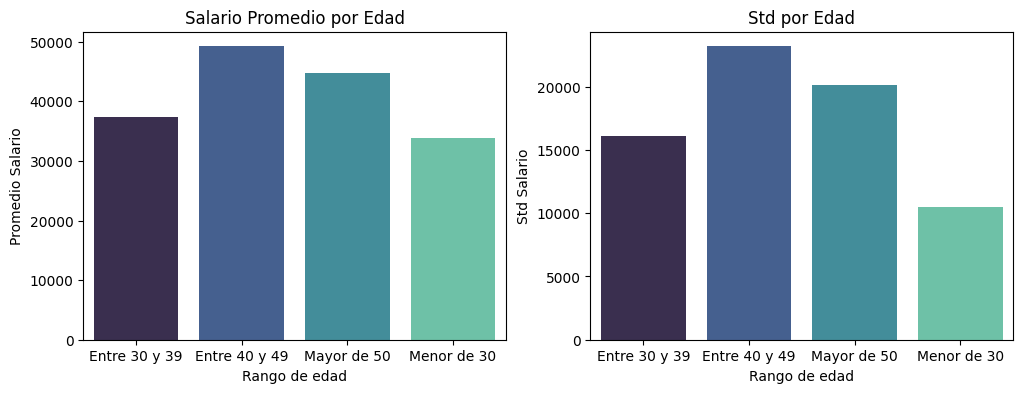

In [ ]:
dif_salario = df.groupby(["Rango de edad"])["Salario Actual"].mean().reset_index(name = "Promedio Salario")
dif_salario["Promedio Salario"] = np.round(dif_salario["Promedio Salario"], 2)

std_salario = df.groupby(["Rango de edad"])["Salario Actual"].std().reset_index(name = "Std Salario")
std_salario["Std Salario"] = np.round(std_salario["Std Salario"], 2)

dif_salario = dif_salario.merge(std_salario, how = "left", on = "Rango de edad")


fig, ax = plt.subplots(ncols = 2, nrows = 1, figsize = (12,4))

sns.barplot(data = dif_salario, x = "Rango de edad", y = "Promedio Salario", ax = ax[0], palette = "mako")
sns.barplot(data = dif_salario, x = "Rango de edad", y = "Std Salario", ax = ax[1], palette = "mako")

ax[0].set_title("Salario Promedio por Edad")
ax[1].set_title("Std por Edad")

plt.show()

8. **Empleados con Antigüedad en un Rango Específico**

   - **Enunciado:** Filtra a los empleados cuya antigüedad esté en el rango de 5 a 10 años. Calcula el salario promedio de estos empleados por departamento.

In [ ]:
antiguedad = df[(df["Años en Empresa"] > 5) & (df["Años en Empresa"] < 10)]
antiguedad.groupby("Departamento")["Salario Actual"].mean().round(2).reset_index(name = "Salario Prom. Empl. 5-10 años")

,Departamento,Salario Prom. Empl. 5-10 años
0,Contabilidad,30452.00
1,Diseño,25176.00
2,I + D,28044.00
3,Ingeniería,36797.67
4,Mercado,34764.00


9. **Creación de un Índice de Satisfacción**

   - **Enunciado:** Crea un índice de satisfacción basado en el salario y la antigüedad, donde un mayor salario y mayor antigüedad generen un índice más alto. Usa una fórmula ponderada para calcular este índice y muestra los 5 empleados con el mayor índice.

Necesitamos definir cómo ponderar el salario y la antigüedad para calcular el índice. Por ejemplo, podríamos usar la siguiente fórmula ponderada, en donde alpha y beta es el nivel de importancia relativa que le denotamos respectivamente a cada variable:

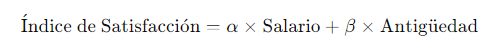

Y por ultimo aplicaremos una normalizacion para tener el indice entre 0 y 1 mediante la siguiente formula:

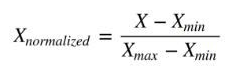

In [ ]:
alpha = 0.4 #Indice de importancia
beta = 0.2 #Indice de importancia

df["Indica Satisfaccion"] = (alpha*df["Salario Actual"] + beta*df["Años en Empresa"])

max_index = df["Indica Satisfaccion"].max()
min_index = df["Indica Satisfaccion"].min()

df["Indica Satisfaccion"] = (df["Indica Satisfaccion"] - min_index) / (max_index - min_index)
df.sort_values(by = "Indica Satisfaccion", ascending=False).head(5)

,Matrícula,Apellido,Nombre,Categoría,Departamento,Sección,Salario Actual,Fecha ingreso,Fch nacimiento,Salario Anualizado,Fecha Corte,Años en Empresa,Salario Anterior,Dif. Salario Anterior/Actual,Incremento de Salario,Edad,Rango de edad,Indica Satisfaccion
5,1056,Gonzales,Joe,Director Unidad,Administración,Copiadoras,116511,2004-06-15,1962-04-15,1398132,2024-08-01,20.114911,115787,724,0.6,62,Mayor de 50,1.000000
9,1076,McKormick,Brad,Ingeniero Jefe,Ingeniería,Copiadoras,105753,2014-01-27,1975-03-09,1269036,2024-08-01,10.503420,115787,-10034,-8.7,49,Entre 40 y 49,0.886945
99,1950,Smith,Rich,Group Mgr.,Mercado,Fax,104565,1981-10-04,1951-03-09,1254780,2024-08-01,42.796170,115787,-11222,-9.7,73,Mayor de 50,0.874635
81,1725,Farley,Sam,Director Unidad,Mercado,Copiadoras,97096,1978-02-02,1954-06-02,1165152,2024-08-01,46.462380,115787,-18691,-16.1,70,Mayor de 50,0.796198
76,1696,Abdul,Cathy,Ing. Mecánico,Ingeniería,Copiadoras,79307,1984-10-12,1940-01-16,951684,2024-08-01,39.775650,115787,-36480,-31.5,84,Mayor de 50,0.609302


10. **Impacto de la Generación en el Salario**

    - **Enunciado:** Realiza un análisis de regresión para estudiar el impacto de la generación (como variable categórica) en el salario. Muestra el coeficiente de regresión para cada generación y realiza un análisis de la significancia de estos coeficientes.